In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('iris.csv')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [5]:
X = df.drop('species', axis = 1).values
y = df['species'].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
err = []

for k in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    err.append(knn.score(X_test, y_test))

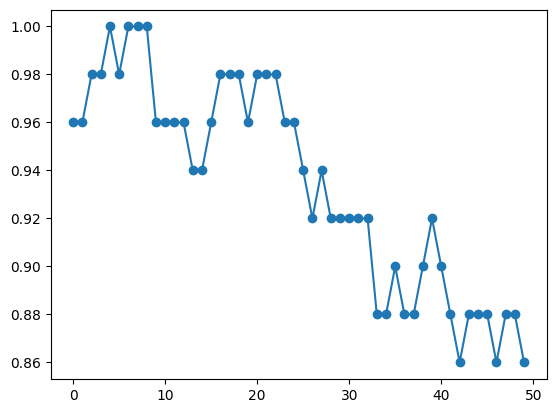

In [9]:
plt.plot(err, 'o-')

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

In [17]:
knn = KNeighborsClassifier(n_neighbors = 15)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

<Axes: >

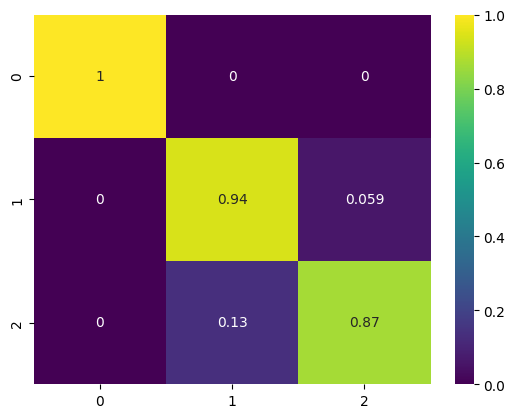

In [18]:
y_pred = knn.predict(X_test)

sns.heatmap(confusion_matrix(y_test, y_pred, normalize = 'true'), annot = True, cmap = 'viridis')

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       0.89      0.94      0.91        17
   virginica       0.93      0.87      0.90        15

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50



In [20]:
from sklearn.neighbors import KNeighborsRegressor

In [21]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [26]:
X = df.drop('species', axis = 1).values
y = df['species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2}).values

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
knn = KNeighborsRegressor(n_neighbors = 5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [30]:
knn.score(X_test, y_test)

0.9608908202064096

In [31]:
from sklearn.metrics import mean_squared_error

In [33]:
np.sqrt(mean_squared_error(y_test, knn.predict(X_test)))

0.1697056274847714